# EDA inicial do LEN-small

Este notebook abre a tabela produzida por `len-summary`. Os vetores LaBSE não são carregados nesta etapa.

**Integrantes:** Gabriel de Santana Santos - 10420595 - 10420595@mackenzista.com.br; Gabriel Erick Mendes - 10420391 - 10420391@mackenzista.com.br; Matheus Teles Magalhães - 10427410 - 10427410@mackenzista.com.br.

**Conteúdo:** análise exploratória inicial, comparação entre classes, visualização e checagem de integridade.

**Histórico:** 09/09/2026 | Grupo | Criação da EDA inicial; 24/09/2026 | Grupo | Revisão, execução integral e preparação para a entrega da disciplina.

## Preparar as ferramentas e localizar os arquivos

Importa as bibliotecas usadas no notebook e informa onde estão: a pasta original do LEN e a tabela-resumo criada na primeira leitura.

In [1]:
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'small_encoder_final'
SUMMARY_PATH = PROJECT_ROOT / 'dados' / 'processados' / 'len_small_summary.csv'
sns.set_theme(style='whitegrid')

## Abrir a tabela de resumo dos grafos

A tabela possui uma linha por grafo do LEN. Se ela ainda não existir, esta célula executa o leitor `len-summary`, que percorre todos os JSONs e gera o arquivo. 
Depois, ela abre a tabela na variável `graphs` e mostra as primeiras linhas para conferência. 
Na primeira execução sem a tabela, a leitura completa pode levar alguns minutos.

In [2]:
if not SUMMARY_PATH.exists():
    subprocess.run([
        'len-summary', '--data-dir', str(DATA_DIR), '--output', str(SUMMARY_PATH)
    ], check=True)

graphs = pd.read_csv(SUMMARY_PATH)
graphs.head()

,file,topic,label,size_mb,directed,multigraph,nodes,unique_node_ids,duplicate_node_ids,edges,...,timestamps_missing,timestamp_coverage,unique_timestamps,timestamps_non_decreasing_in_file,timestamp_start_utc,timestamp_end_utc,duration_hours,interaction_count_sum,interaction_count_mean,interaction_count_max
0,#ARMvTUR_noncampaign_fulldata.json,#ARMvTUR,noncampaign,73.376,True,False,3405,3405,0,3769,...,0,1.0,3346,False,2023-03-25T11:01:55+00:00,2023-03-26T03:59:22+00:00,16.957500,4869.0,1.291855,190.0
1,#Afittifakı___2023-05-23_campaign_fulldata.json,#Afittifakı,campaign,18.368,True,False,288,288,0,1102,...,0,1.0,1090,False,2023-05-23T04:00:53+00:00,2023-05-24T03:39:15+00:00,23.639444,1703.0,1.545372,14.0
2,#AsstanHekimeKalıcıNakil___2023-03-18_campaign...,#AsstanHekimeKalıcıNakil,campaign,24.113,True,False,420,420,0,1398,...,0,1.0,1333,False,2023-03-18T21:02:57+00:00,2023-03-19T03:59:03+00:00,6.935000,2562.0,1.832618,26.0
3,#BeşiktaşınMaçıVar_noncampaign_fulldata.json,#BeşiktaşınMaçıVar,noncampaign,116.843,True,False,4735,4735,0,6188,...,0,1.0,5921,False,2023-05-20T04:34:25+00:00,2023-05-22T03:58:25+00:00,47.400000,7100.0,1.147382,18.0
4,#BirOyKemaleBirOyMerale___2023-05-13_campaign_...,#BirOyKemaleBirOyMerale,campaign,16.178,True,False,815,815,0,800,...,0,1.0,785,False,2023-05-13T07:38:12+00:00,2023-05-14T03:58:22+00:00,20.336111,948.0,1.185000,9.0


## Comparar campanhas e não campanhas

Agrupa os grafos pelas duas classes do dataset: `campaign` e `noncampaign`. 
Para cada grupo, ela apresenta quantos grafos existem e valores típicos de tamanho, duração e cobertura temporal. 
Esses números ajudam a perceber diferenças que podem influenciar os modelos mais adiante.

In [3]:
graphs.groupby('label').agg(
    graphs=('file', 'count'),
    nodes_mean=('nodes', 'mean'),
    nodes_median=('nodes', 'median'),
    edges_mean=('edges', 'mean'),
    duration_hours_median=('duration_hours', 'median'),
    timestamp_coverage_min=('timestamp_coverage', 'min'),
).round(3)

,graphs,nodes_mean,nodes_median,edges_mean,duration_hours_median,timestamp_coverage_min
label,,,,,,
campaign,53,656.415,498.0,1298.453,22.210,1.0
noncampaign,51,3479.235,3227.0,4336.412,23.942,1.0


## Visualizar tamanho e conexão dos grafos

O primeiro gráfico mostra a relação entre número de nós e número de arestas de cada grafo. As escalas são logarítmicas para caberem grafos pequenos e grandes na mesma figura. 
O segundo compara, entre as classes, a fração de nós presente no maior componente conectado; ele ajuda a entender se a rede está concentrada ou fragmentada.

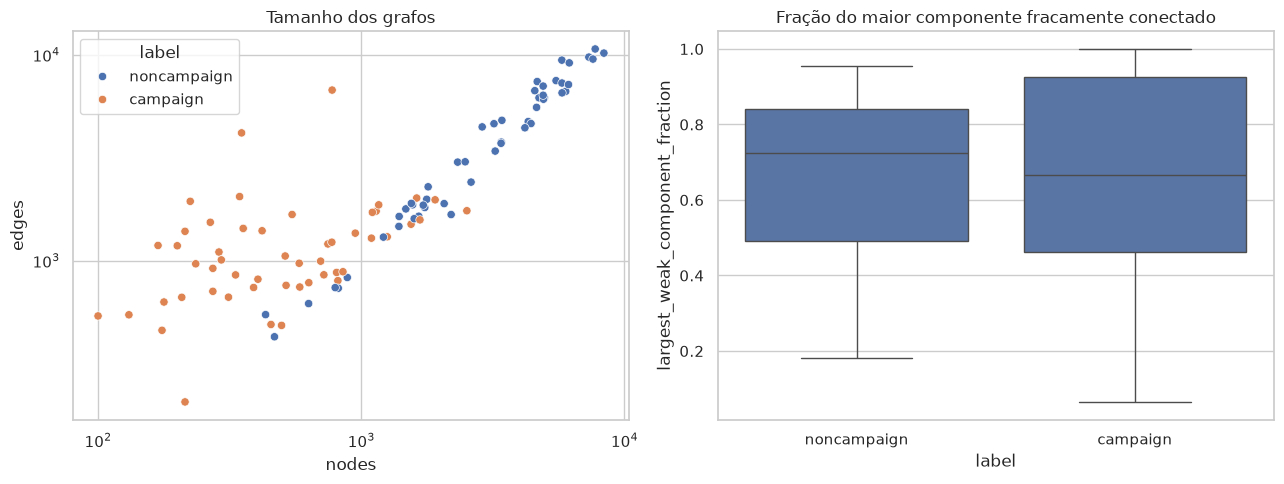

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=graphs, x='nodes', y='edges', hue='label', ax=axes[0])
axes[0].set(xscale='log', yscale='log', title='Tamanho dos grafos')
sns.boxplot(data=graphs, x='label', y='largest_weak_component_fraction', ax=axes[1])
axes[1].set(title='Fração do maior componente fracamente conectado')
plt.tight_layout()

## Procurar problemas de qualidade dos dados

Checagem de segurança para a pesquisa. Ela lista somente os grafos com identificadores de nó duplicados, arestas ligadas a nós inexistentes ou timestamps ausentes. 
O resultado vazio é bom: significa que nenhum desses problemas foi encontrado pelos critérios verificados.

In [5]:
integrity_columns = [
    'file', 'duplicate_node_ids', 'missing_edge_endpoints',
    'timestamps_missing', 'timestamp_coverage',
]
graphs.loc[
    (graphs['duplicate_node_ids'] > 0)
    | (graphs['missing_edge_endpoints'] > 0)
    | (graphs['timestamp_coverage'] < 1),
    integrity_columns,
]

,file,duplicate_node_ids,missing_edge_endpoints,timestamps_missing,timestamp_coverage
